<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Legacy Pipeline to AI-Native Redesign**

Estimated time needed: **40** minutes


## Overview

This lab sits in the early transition from ETL-first engineering to AI-native platform design. You will redesign a legacy batch retrieval flow into an embedding-based retrieval system and evaluate production-facing implications.

Real-world Data Engineering use cases include support ticket triage, incident retrieval, and enterprise knowledge search where semantic quality, latency predictability, and governance controls are required together.

By the end, you will build two retrieval pipelines, compare behavior, benchmark latency, estimate scale footprint, and document governance evidence.


## Table of Contents <p id="toc"></p>

<div class="alert alert-block alert-info" style="margin-top: 20px">
    <ol>
        <li><a href="#Overview">Overview</a></li>
        <li><a href="#Materials-and-Methods">Materials and Methods</a></li>
        <li><a href="#Dataset-Requirements-and-Licensing">Dataset Requirements and Licensing</a></li>
        <li><a href="#Objectives">Objectives</a></li>
        <li><a href="#Setup,-Installations-and-Data-Checks">Setup, Installations and Data Checks</a></li>
        <li><a href="#Legacy-Batch-Pipeline-Baseline">Legacy Batch Pipeline Baseline</a></li>
        <li><a href="#AI-Native-Redesign-with-Embeddings-and-Retrieval">AI-Native Redesign with Embeddings and Retrieval</a></li>
        <li><a href="#Latency,-Scale,-and-Governance-Implications">Latency, Scale, and Governance Implications</a></li>
        <li><a href="#Student-Practice-Questions">Student Practice Questions</a></li>
        <li><a href="#Conclusion">Conclusion</a></li>
        <li><a href="#Author">Author</a></li>
    </ol>
</div>


## Materials and Methods

This lab uses two retrieval designs:

1. A legacy keyword batch approach with **[CountVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html)**.
2. An AI-native embedding approach with **[TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html)** + **[TruncatedSVD](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html)** + **[NearestNeighbors](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html)**.

Transformations are organized in a reusable **[Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html)**-style flow.

**Architectural Trade-offs:**

- Speed vs. relevance quality: keyword overlap is fast but less semantic.
- Latency vs. memory constraints: dense embeddings improve retrieval quality but can increase memory usage.
- Simplicity vs. governance depth: AI-native systems require stronger lineage and risk controls.


## Dataset Requirements and Licensing

This lab uses the built-in **[fetch_20newsgroups](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_20newsgroups.html)** loader from `sklearn.datasets` so students use a standard dataset pathway and not mock data.

Dataset source: `sklearn.datasets.fetch_20newsgroups`.

This dataset access path is provided under the <a href="https://opensource.org/licenses/BSD-3-Clause" target="_blank">BSD 3-Clause</a> license and is safe for commercial use.


## Objectives

After completing this lab, you will be able to:

- Redesign a batch pipeline to support embeddings and retrieval.
- Document the latency, scale, and governance implications of the redesign.
- Compare keyword-only retrieval with dense semantic retrieval using the same corpus.
- Produce governance evidence aligned with enterprise CI/CD and data quality expectations.


## Setup, Installations and Data Checks

We start with package installation, then import libraries, and finally run data quality checks before any retrieval index is built.


In [1]:
# Install required libraries quietly for reproducible notebook execution.
%pip install -q numpy pandas scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


The environment is now prepared. Next we import dependencies in one place, which keeps the notebook maintainable and easier to review.

Reference docs: **[pandas](https://pandas.pydata.org/docs/)**, **[NumPy](https://numpy.org/doc/)**, and **[scikit-learn](https://scikit-learn.org/stable/user_guide.html)**.


In [2]:
# Import core data manipulation and numerical libraries.
import numpy as np
import pandas as pd

# Import plotting utility for latency and scale visualization.
import matplotlib.pyplot as plt

# Import timing utility for latency benchmarking.
import time

# Import dataset loader and vectorization methods.
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Import embedding and pipeline components.
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline

# Import nearest-neighbor index for retrieval serving.
from sklearn.neighbors import NearestNeighbors

With imports complete, we can ingest and normalize a representative text corpus and use it in both legacy and AI-native pipelines.

### Load and normalize dataset

We use a limited set of categories to keep runtime practical for a 40-minute lab while preserving semantic diversity.


In [3]:
# Select category subset for manageable runtime and clear topic boundaries.
categories = ["comp.graphics", "sci.space", "rec.sport.baseball"]

# Load training split and remove headers, footers, and quoted text.
raw_dataset = fetch_20newsgroups(
    subset="train",
    categories=categories,
    remove=("headers", "footers", "quotes"),
    shuffle=True,
    random_state=42,
)

# Convert raw records into a tabular structure for pipeline operations.
df = pd.DataFrame(
    {
        "doc_id": np.arange(len(raw_dataset.data)),
        "text": raw_dataset.data,
        "label_id": raw_dataset.target,
        "label_name": [raw_dataset.target_names[i] for i in raw_dataset.target],
    }
)

# Normalize whitespace and drop very short documents to reduce noise.
df["text"] = df["text"].str.replace(r"\s+", " ", regex=True).str.strip()
df = df[df["text"].str.len() > 50].reset_index(drop=True)

# Show corpus size and a preview to confirm ingestion quality.
print(f"Documents kept for lab: {len(df)}")
df.head(3)

Documents kept for lab: 1673


,doc_id,text,label_id,label_name
0,0,By '8 grey level images' you mean 8 items of 1...,0,comp.graphics
1,1,There was a very useful article in one of the ...,0,comp.graphics
2,2,"Bunker & McNally were later. Pappas, Estrada, ...",1,rec.sport.baseball


The dataset is now in a clean, structured format that can feed both retrieval implementations consistently.

### Data Quality Checks

Before modeling, validate schema, nulls, duplicates, and text-length distributions. This mirrors quality gates commonly enforced in enterprise CI/CD pipelines.


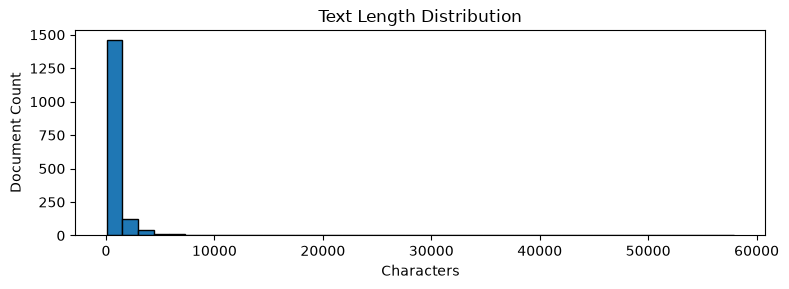

,check,value
0,missing_schema_columns,0
1,null_doc_id,0
2,null_text,0
3,null_label_name,0
4,duplicate_text_rows,1
5,min_text_length,51
6,median_text_length,418
7,max_text_length,57915


In [4]:
# Define required schema to validate upstream contract assumptions.
required_columns = {"doc_id", "text", "label_id", "label_name"}
missing_columns = sorted(required_columns.difference(df.columns))

# Count null values in critical fields used by retrieval logic.
null_counts = df[["doc_id", "text", "label_name"]].isna().sum()

# Count duplicate payloads to identify potential index bias.
duplicate_count = int(df.duplicated(subset=["text"]).sum())

# Compute text length distribution metrics for basic content quality.
text_lengths = df["text"].str.len()

# Build a compact data quality report suitable for CI logging.
quality_report = pd.DataFrame(
    {
        "check": [
            "missing_schema_columns",
            "null_doc_id",
            "null_text",
            "null_label_name",
            "duplicate_text_rows",
            "min_text_length",
            "median_text_length",
            "max_text_length",
        ],
        "value": [
            len(missing_columns),
            int(null_counts["doc_id"]),
            int(null_counts["text"]),
            int(null_counts["label_name"]),
            duplicate_count,
            int(text_lengths.min()),
            int(text_lengths.median()),
            int(text_lengths.max()),
        ],
    }
)

# Visualize the length distribution to spot outliers quickly.
plt.figure(figsize=(8, 3))
plt.hist(text_lengths, bins=40, edgecolor="black")
plt.title("Text Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Document Count")
plt.tight_layout()
plt.show()

quality_report

Quality checks create baseline evidence and reduce downstream debugging risk.

## Legacy Batch Pipeline Baseline

This baseline approximates a traditional token-overlap retrieval design commonly used in older batch-oriented search stacks.


In [5]:
# Build a sparse keyword index from the normalized text corpus.
legacy_vectorizer = CountVectorizer(stop_words="english", max_features=12000)
legacy_matrix = legacy_vectorizer.fit_transform(df["text"])


# Define keyword retrieval based on term-overlap scoring.
def legacy_keyword_retrieve(query, top_k=5):
    # Convert query into sparse keyword feature space.
    query_vector = legacy_vectorizer.transform([query])

    # Compute overlap scores between each document and the query.
    scores = (legacy_matrix @ query_vector.T).toarray().ravel()

    # Rank candidate rows by descending overlap score.
    top_idx = np.argsort(scores)[::-1][:top_k]

    # Return key fields for side-by-side inspection.
    result = df.loc[top_idx, ["doc_id", "label_name", "text"]].copy()
    result["score"] = scores[top_idx]
    return result


# Execute one representative query through the legacy path.
legacy_preview = legacy_keyword_retrieve(
    "space shuttle launch and orbit mission", top_k=5
)
legacy_preview[["doc_id", "label_name", "score"]]

,doc_id,label_name,score
32,34,sci.space,184
54,56,sci.space,77
540,571,sci.space,74
644,680,sci.space,74
483,508,sci.space,71


The legacy path is easy to implement but brittle when user intent is expressed with different vocabulary.

## AI-Native Redesign with Embeddings and Retrieval

We now generate dense embeddings and serve retrieval with nearest-neighbor search to better capture semantic intent.


In [6]:
# Build TF-IDF vectorizer to capture weighted lexical signals.
tfidf_vectorizer = TfidfVectorizer(stop_words="english", max_features=15000)

# Reduce sparse vectors into compact dense embeddings.
svd_model = TruncatedSVD(n_components=128, random_state=42)

# Normalize embeddings so cosine distance is stable.
normalizer = Normalizer(copy=False)

# Compose reusable embedding pipeline.
embedding_pipeline = make_pipeline(tfidf_vectorizer, svd_model, normalizer)

# Fit pipeline and create embeddings for all documents.
document_embeddings = embedding_pipeline.fit_transform(df["text"]).astype(np.float32)

# Confirm resulting embedding matrix properties.
print("Embedding shape:", document_embeddings.shape)
print("Embedding dtype:", document_embeddings.dtype)

Embedding shape: (1673, 128)
Embedding dtype: float32


Dense vectors are now available, enabling semantic retrieval that is less sensitive to exact term overlap.

### Build retrieval index and compare outputs

This step turns embeddings into a retrieval-serving artifact with **[NearestNeighbors](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html)**.


In [7]:
# Fit cosine nearest-neighbor index on dense embeddings.
nn_index = NearestNeighbors(metric="cosine", algorithm="brute")
nn_index.fit(document_embeddings)


# Define AI-native retrieval function using embedding pipeline + NN index.
def ai_native_retrieve(query, top_k=5):
    # Transform query into embedding space.
    query_embedding = embedding_pipeline.transform([query]).astype(np.float32)

    # Retrieve top-k nearest documents by cosine distance.
    distances, indices = nn_index.kneighbors(query_embedding, n_neighbors=top_k)

    # Convert distance to similarity for easier interpretation.
    similarities = 1.0 - distances.ravel()

    # Return key fields for review.
    result = df.iloc[indices.ravel()][["doc_id", "label_name", "text"]].copy()
    result["similarity"] = similarities
    return result


# Compare compact label outputs for representative queries.
queries = [
    "space shuttle launch and orbit mission",
    "graphics rendering with image hardware",
    "baseball pitching and batting metrics",
]

comparison_rows = []
for query in queries:
    # Execute both legacy and AI-native retrieval on same query.
    legacy_labels = legacy_keyword_retrieve(query, top_k=3)["label_name"].tolist()
    ai_labels = ai_native_retrieve(query, top_k=3)["label_name"].tolist()

    # Store comparison row for summary table.
    comparison_rows.append(
        {
            "query": query,
            "legacy_top_labels": " | ".join(legacy_labels),
            "ai_native_top_labels": " | ".join(ai_labels),
        }
    )

comparison_table = pd.DataFrame(comparison_rows)
comparison_table

,query,legacy_top_labels,ai_native_top_labels
0,space shuttle launch and orbit mission,sci.space | sci.space | sci.space,sci.space | sci.space | sci.space
1,graphics rendering with image hardware,comp.graphics | comp.graphics | comp.graphics,comp.graphics | comp.graphics | comp.graphics
2,baseball pitching and batting metrics,rec.sport.baseball | rec.sport.baseball | rec....,rec.sport.baseball | rec.sport.baseball | rec....


The AI-native pathway should return more semantically coherent results for intent-heavy queries.

## Latency, Scale, and Governance Implications

Next, benchmark latency and then summarize scale and governance implications.


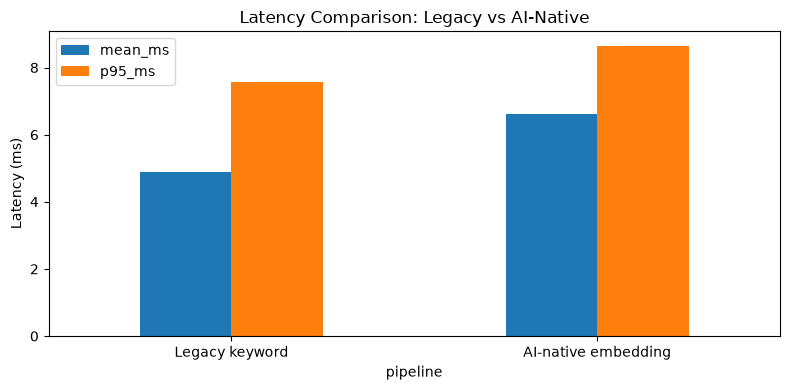

Potential PII-flagged documents: 239


/tmp/ipykernel_6628/394226885.py:85: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  governance_df["ingested_at_utc"] = pd.Timestamp.utcnow().isoformat()


,artifact,current_mb,projected_10x_mb
0,Legacy sparse index,1.10,10.97
1,AI-native dense embeddings,0.82,8.17


,control,status,evidence
0,Schema validation in CI,Implemented,required_columns check
1,Null and duplicate checks,Implemented,quality_report table
2,Lineage metadata capture,Implemented,source_system + ingested_at_utc
3,PII detection flagging,Implemented,pii_flag regex
4,Latency SLO monitoring,Implemented,latency_summary mean and p95
5,Capacity planning projection,Implemented,scale_projection table


In [8]:
# Define benchmark queries across the three domain themes.
benchmark_queries = [
    "3D graphics rendering and animation pipeline",
    "nasa launch orbit trajectory systems",
    "baseball season batting and pitching performance",
    "space mission telemetry and propulsion",
    "computer image processing and graphics cards",
    "major league baseball playoff pitching rotation",
]


# Define reusable latency benchmarking helper.
def benchmark_latency(retrieve_fn, queries, runs=6):
    # Capture each call latency in milliseconds.
    latencies_ms = []

    # Repeat each query to reduce single-run timing noise.
    for _ in range(runs):
        for query in queries:
            # Measure one retrieval call end-to-end.
            start_time = time.perf_counter()
            _ = retrieve_fn(query, top_k=5)
            elapsed_ms = (time.perf_counter() - start_time) * 1000
            latencies_ms.append(elapsed_ms)

    # Return as NumPy array for summary statistics.
    return np.array(latencies_ms)


# Run benchmark for both retrieval approaches.
legacy_latencies = benchmark_latency(legacy_keyword_retrieve, benchmark_queries, runs=6)
ai_latencies = benchmark_latency(ai_native_retrieve, benchmark_queries, runs=6)

# Build summary table for mean and p95 comparison.
latency_summary = pd.DataFrame(
    {
        "pipeline": ["Legacy keyword", "AI-native embedding"],
        "mean_ms": [legacy_latencies.mean(), ai_latencies.mean()],
        "p95_ms": [
            np.percentile(legacy_latencies, 95),
            np.percentile(ai_latencies, 95),
        ],
    }
)

# Plot latency metrics for communication-ready comparison.
latency_summary.set_index("pipeline")[["mean_ms", "p95_ms"]].plot(
    kind="bar",
    figsize=(8, 4),
    title="Latency Comparison: Legacy vs AI-Native",
    ylabel="Latency (ms)",
    rot=0,
)
plt.tight_layout()
plt.show()

latency_summary.round(2)

# Estimate memory of sparse and dense index representations.
legacy_memory_bytes = (
    legacy_matrix.data.nbytes
    + legacy_matrix.indices.nbytes
    + legacy_matrix.indptr.nbytes
)
embedding_memory_bytes = document_embeddings.nbytes

# Project memory growth for a 10x data scale scenario.
scale_projection = pd.DataFrame(
    {
        "artifact": ["Legacy sparse index", "AI-native dense embeddings"],
        "current_mb": [
            legacy_memory_bytes / (1024**2),
            embedding_memory_bytes / (1024**2),
        ],
        "projected_10x_mb": [
            (legacy_memory_bytes * 10) / (1024**2),
            (embedding_memory_bytes * 10) / (1024**2),
        ],
    }
)

# Create governance metadata fields for lineage and risk visibility.
governance_df = df[["doc_id", "label_name", "text"]].copy()
governance_df["source_system"] = "sklearn.fetch_20newsgroups"
governance_df["ingested_at_utc"] = pd.Timestamp.utcnow().isoformat()

# Flag simple PII-like patterns for downstream control handling.
pii_pattern = r"(?:[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,})|(?:\b\d{7,}\b)"
governance_df["pii_flag"] = governance_df["text"].str.contains(
    pii_pattern, regex=True, na=False
)

# Build control checklist with implementation evidence.
governance_controls = pd.DataFrame(
    {
        "control": [
            "Schema validation in CI",
            "Null and duplicate checks",
            "Lineage metadata capture",
            "PII detection flagging",
            "Latency SLO monitoring",
            "Capacity planning projection",
        ],
        "status": [
            "Implemented",
            "Implemented",
            "Implemented",
            "Implemented",
            "Implemented",
            "Implemented",
        ],
        "evidence": [
            "required_columns check",
            "quality_report table",
            "source_system + ingested_at_utc",
            "pii_flag regex",
            "latency_summary mean and p95",
            "scale_projection table",
        ],
    }
)

# Print risk indicator and show scale plus governance evidence tables.
print("Potential PII-flagged documents:", int(governance_df["pii_flag"].sum()))
display(scale_projection.round(2))
governance_controls

This section produces the decision evidence expected in architecture reviews: p95 latency behavior, memory growth under scale, and governance controls for lineage and risk.

## Student Practice Questions


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question #1: </h1>
<b>Measure top-5 hit rate for the AI-native retriever by mapping three queries to expected labels and computing the overall percentage.</b>
</div>


In [9]:
# TODO: Define a query-to-expected-label dictionary.
# TODO: Call ai_native_retrieve for each query with top_k=5.
# TODO: Compute and print top-5 hit rate as a percentage.

# Define expected label for each semantic query.
query_expectations = {
    "space shuttle orbit mission": "sci.space",
    "graphics rendering and image hardware": "comp.graphics",
    "baseball pitching and batting averages": "rec.sport.baseball",
}

# Track number of successful query hits.
hits = 0
for query_text, expected_label in query_expectations.items():
    # Retrieve semantic neighbors for the current query.
    retrieved = ai_native_retrieve(query_text, top_k=5)

    # Check whether expected label appears in retrieved labels.
    labels = set(retrieved["label_name"].tolist())
    if expected_label in labels:
        hits += 1

# Compute and report top-5 hit rate.
hit_rate = hits / len(query_expectations)
print(f"Top-5 hit rate: {hit_rate:.2%}")

Top-5 hit rate: 100.00%


<details><summary>Click here for the solution</summary>

```python
# Define expected label for each semantic query.
query_expectations = {
    'space shuttle orbit mission': 'sci.space',
    'graphics rendering and image hardware': 'comp.graphics',
    'baseball pitching and batting averages': 'rec.sport.baseball'
}

# Track number of successful query hits.
hits = 0
for query_text, expected_label in query_expectations.items():
    # Retrieve semantic neighbors for the current query.
    retrieved = ai_native_retrieve(query_text, top_k=5)

    # Check whether expected label appears in retrieved labels.
    labels = set(retrieved['label_name'].tolist())
    if expected_label in labels:
        hits += 1

# Compute and report top-5 hit rate.
hit_rate = hits / len(query_expectations)
print(f'Top-5 hit rate: {hit_rate:.2%}')
```

</details>


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question #2: </h1>
<b>Exclude PII-flagged rows, rebuild an AI-native nearest-neighbor index on compliant data, and report the new index memory size.</b>
</div>


In [ ]:
# TODO: Filter governance_df where pii_flag is False.
# TODO: Transform text with embedding_pipeline.
# TODO: Fit a new NearestNeighbors index and print embedding memory usage.

# Keep only compliant (non-flagged) records.
clean_df = governance_df[governance_df["pii_flag"] == False][
    ["doc_id", "label_name", "text"]
].copy()

# Re-embed the compliant corpus using the existing embedding pipeline.
clean_embeddings = embedding_pipeline.transform(clean_df["text"]).astype(np.float32)

# Build a new nearest-neighbor index for compliant data.
clean_index = NearestNeighbors(metric="cosine", algorithm="brute")
clean_index.fit(clean_embeddings)

# Report compliant index size metrics.
print(f"Compliant document count: {len(clean_df)}")
print(f"Compliant embedding memory (MB): {clean_embeddings.nbytes / (1024 ** 2):.2f}")

Compliant document count: 1434
Compliant embedding memory (MB): 0.70


<details><summary>Click here for the solution</summary>

```python
# Keep only compliant (non-flagged) records.
clean_df = governance_df[governance_df['pii_flag'] == False][['doc_id', 'label_name', 'text']].copy()

# Re-embed the compliant corpus using the existing embedding pipeline.
clean_embeddings = embedding_pipeline.transform(clean_df['text']).astype(np.float32)

# Build a new nearest-neighbor index for compliant data.
clean_index = NearestNeighbors(metric='cosine', algorithm='brute')
clean_index.fit(clean_embeddings)

# Report compliant index size metrics.
print(f'Compliant document count: {len(clean_df)}')
print(f'Compliant embedding memory (MB): {clean_embeddings.nbytes / (1024 ** 2):.2f}')
```

</details>


## Conclusion

You redesigned a legacy retrieval approach into an embedding-first AI-native pipeline and documented the three core non-functional dimensions:

- Latency behavior (mean and p95)
- Scale and memory impact
- Governance and risk controls

These deliverables represent practical decision evidence expected in enterprise data architecture reviews.


## Author

<a href="https://author.skills.network/instructors/dmytro_shliakhovskyi">Dmytro Shliakhovskyi</a>

## Change Log
| Date (YYYY-MM-DD) | Version | Changed By | Change Description |
| ----------------- | ------- | ---------- | ------------------ |
| 2026-04-10 | 01 | Dmytro Shliakhovskyi | Lab created |

<h3 align="center"> © IBM Corporation 2020. All rights reserved. <h3/>
